# 1. Setup and Imports

In [3]:
# -*- coding: utf-8 -*-
import random
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.multioutput import MultiOutputRegressor
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# 2. Data Loading

In [26]:
def load_gefcom2014(file_path='L1-train.csv', zone=None, min_year=2006, max_year=2010):
    """
    Load GEFCom2014 data with custom timestamp parsing.
    Timestamp format: MMDDYY HH:MM with variable digit counts.
    Example: '1182009 23:00' -> 2009-01-18 23:00
    """
    df = pd.read_csv(file_path)
    print("First 5 rows of the file:")
    print(df.head())
    print("\nColumn names:", df.columns.tolist())

    # Detect timestamp column
    if 'TIMESTAMP' in df.columns:
        time_col = 'TIMESTAMP'
    else:
        possible = ['TIME', 'ESTAMP', 'datetime', 'Date']
        time_col = next((c for c in possible if c in df.columns), None)
        if time_col is None:
            raise KeyError("No timestamp column found (TIMESTAMP, TIME, etc.).")
    print(f"Using timestamp column: {time_col}")

    # Custom parser for variable-length MMDDYY HH:MM
    def parse_ts(ts_str):
        ts_str = str(ts_str).strip()
        if ' ' not in ts_str:
            return pd.NaT
        date_part, time_part = ts_str.split()
        hour_min = time_part.split(':')
        if len(hour_min) != 2:
            return pd.NaT
        hour, minute = hour_min
        hour = hour.zfill(2)
        minute = minute.zfill(2)

        # Extract year: last 2 or 4 digits
        year_part = None
        if len(date_part) >= 4 and date_part[-4:].isdigit():
            # last 4 digits are year
            year_part = date_part[-4:]
            rest = date_part[:-4]
        elif len(date_part) >= 2 and date_part[-2:].isdigit():
            # last 2 digits are year (e.g., 01 for 2001)
            year_part = date_part[-2:]
            rest = date_part[:-2]
        else:
            return pd.NaT

        # Convert year to 4-digit
        if len(year_part) == 2:
            year = 2000 + int(year_part)
        else:
            year = int(year_part)

        # Month and day are in 'rest'
        # Try to split rest into month and day (month first)
        month = None
        day = None
        # Try month = 2 digits first
        if len(rest) >= 2:
            month_candidate = int(rest[:2])
            if 1 <= month_candidate <= 12:
                month = month_candidate
                rest_day = rest[2:]
            else:
                month_candidate = int(rest[:1])
                if 1 <= month_candidate <= 12:
                    month = month_candidate
                    rest_day = rest[1:]
                else:
                    return pd.NaT
        elif len(rest) == 1:
            month_candidate = int(rest)
            if 1 <= month_candidate <= 12:
                month = month_candidate
                rest_day = ''
            else:
                return pd.NaT
        else:
            return pd.NaT

        if len(rest_day) > 0:
            day = int(rest_day)
        else:
            day = 1  # fallback (should not happen)

        # Validate day
        if day < 1 or day > 31:
            return pd.NaT

        # Build datetime
        try:
            dt = pd.Timestamp(year=year, month=month, day=day,
                              hour=int(hour), minute=int(minute))
        except:
            return pd.NaT
        return dt

    df['datetime'] = df[time_col].astype(str).apply(parse_ts)
    # Drop rows where datetime could not be parsed
    before = len(df)
    df = df.dropna(subset=['datetime'])
    print(f"Dropped {before - len(df)} rows with invalid timestamps.")

    # Filter by zone if provided
    if zone is not None:
        if 'ZONEID' in df.columns:
            df = df[df['ZONEID'] == zone].copy()
        else:
            print("No ZONEID column found; ignoring zone filter.")

    # Filter by year range
    df = df[(df['datetime'].dt.year >= min_year) & (df['datetime'].dt.year <= max_year)].copy()
    print(f"Kept {len(df)} rows with year between {min_year} and {max_year}")

    # Load column detection
    possible_load = ['LOAD', 'load', 'Load', 'Demand', 'demand']
    load_col = next((c for c in possible_load if c in df.columns), None)
    if load_col is None:
        if len(df.columns) > 1:
            load_col = df.columns[1]
        else:
            raise KeyError("Could not find a load column.")
    print(f"Using load column: {load_col}")

    df.rename(columns={load_col: 'LOAD'}, inplace=True)
    df['LOAD'] = pd.to_numeric(df['LOAD'], errors='coerce')
    before = len(df)
    df = df.dropna(subset=['LOAD'])
    print(f"Dropped {before - len(df)} rows with NaN LOAD, remaining: {len(df)}")

    # Weather columns (w1..w25)
    weather_cols = [c for c in df.columns if c.lower().startswith('w') and c[1:].isdigit()]
    if not weather_cols:
        exclude = ['datetime', 'LOAD', 'ZONEID', time_col]
        weather_cols = [c for c in df.columns if c not in exclude and np.issubdtype(df[c].dtype, np.number)]
        print(f"No w* columns found; using numeric columns as features: {weather_cols}")

    # Time features
    df['Hour'] = df['datetime'].dt.hour
    df['DayOfWeek'] = df['datetime'].dt.dayofweek
    df['DayOfMonth'] = df['datetime'].dt.day
    df['Month'] = df['datetime'].dt.month

    df['HourSin'] = np.sin(2 * np.pi * df['Hour'] / 24)
    df['HourCos'] = np.cos(2 * np.pi * df['Hour'] / 24)
    df['DayOfWeekSin'] = np.sin(2 * np.pi * df['DayOfWeek'] / 7)
    df['DayOfWeekCos'] = np.cos(2 * np.pi * df['DayOfWeek'] / 7)
    df['DayOfMonthSin'] = np.sin(2 * np.pi * df['DayOfMonth'] / 31)
    df['DayOfMonthCos'] = np.cos(2 * np.pi * df['DayOfMonth'] / 31)
    df['MonthSin'] = np.sin(2 * np.pi * df['Month'] / 12)
    df['MonthCos'] = np.cos(2 * np.pi * df['Month'] / 12)
    df['IsWeekend'] = df['DayOfWeek'].isin([5,6]).astype(int)

    # Final feature list
    feature_cols = ['LOAD'] + weather_cols + [
        'Hour', 'DayOfWeek', 'DayOfMonth', 'Month',
        'HourSin', 'HourCos', 'DayOfWeekSin', 'DayOfWeekCos',
        'DayOfMonthSin', 'DayOfMonthCos', 'MonthSin', 'MonthCos',
        'IsWeekend'
    ]
    feature_cols = [c for c in feature_cols if c in df.columns]
    df = df.dropna(subset=feature_cols)

    print(f"\nLoaded {len(df)} hourly records after cleaning.")
    print("Feature columns:", feature_cols)
    return df, feature_cols, 'LOAD'

# 3. Sequence Preparation

In [5]:
def prepare_enhanced_data(df, input_steps=24, output_steps=12, target_col='LOAD', feature_cols=None):
    """Create sequences, split, scale, and build decoder inputs."""
    if feature_cols is None:
        feature_cols = [target_col]

    # Ensure data is sorted by time
    df = df.sort_values('datetime').reset_index(drop=True)

    # Separate target and features (unscaled)
    target_data = df[[target_col]].values
    feature_data = df[feature_cols].drop(columns=[target_col]).values

    # Build raw sequences
    X_raw, y_raw = [], []
    for i in range(len(df) - input_steps - output_steps + 1):
        seq_x = df[feature_cols].iloc[i:i+input_steps].values
        seq_y = df[target_col].iloc[i+input_steps:i+input_steps+output_steps].values
        X_raw.append(seq_x)
        y_raw.append(seq_y)

    X_raw = np.array(X_raw)
    y_raw = np.array(y_raw)

    # Split chronologically
    X_train_raw, X_temp_raw, y_train_raw, y_temp_raw = train_test_split(
        X_raw, y_raw, test_size=0.3, shuffle=False
    )
    X_val_raw, X_test_raw, y_val_raw, y_test_raw = train_test_split(
        X_temp_raw, y_temp_raw, test_size=0.5, shuffle=False
    )

    # Fit scalers on training only
    feature_scaler = StandardScaler()
    target_scaler = MinMaxScaler()

    feature_scaler.fit(X_train_raw[:, :, 1:].reshape(-1, len(feature_cols)-1))
    target_scaler.fit(y_train_raw.reshape(-1, 1))

    # Scaling functions
    def scale_X(X):
        X_scaled = np.zeros_like(X)
        X_scaled[:, :, 0] = target_scaler.transform(X[:, :, 0].reshape(-1,1)).reshape(X.shape[0], X.shape[1])
        X_scaled[:, :, 1:] = feature_scaler.transform(
            X[:, :, 1:].reshape(-1, len(feature_cols)-1)
        ).reshape(X.shape[0], X.shape[1], len(feature_cols)-1)
        return X_scaled

    def scale_y(y):
        return target_scaler.transform(y.reshape(-1,1)).reshape(y.shape)

    X_train = scale_X(X_train_raw)
    X_val   = scale_X(X_val_raw)
    X_test  = scale_X(X_test_raw)

    y_train = scale_y(y_train_raw)
    y_val   = scale_y(y_val_raw)
    y_test  = scale_y(y_test_raw)

    # Decoder input using teacher forcing
    def create_decoder_input(X_batch, y_batch):
        decoder_input = np.zeros((len(X_batch), output_steps, len(feature_cols)))
        for i in range(len(X_batch)):
            decoder_input[i, 0, :] = X_batch[i, -1, :]
            for j in range(1, output_steps):
                decoder_input[i, j, :] = decoder_input[i, j-1, :]
                decoder_input[i, j, 0] = y_batch[i, j-1]  # teacher forcing
        return decoder_input

    decoder_input_train = create_decoder_input(X_train, y_train)
    decoder_input_val   = create_decoder_input(X_val, y_val)
    decoder_input_test  = create_decoder_input(X_test, y_test)

    return (X_train, decoder_input_train, y_train,
            X_val,   decoder_input_val,   y_val,
            X_test,  decoder_input_test,  y_test,
            {'feature_scaler': feature_scaler, 'target_scaler': target_scaler},
            feature_cols)

#   4.  Dual‑Attention Model 

In [6]:
def create_enhanced_model(input_shape, output_steps, num_features,
                          lstm_units=128, dense_units=32, dropout_rate=0.2,
                          num_heads=4, key_dim=64, l2_reg=0.001,
                          learning_rate=0.001):
    """Proposed dual‑attention BiLSTM encoder–decoder."""
    # Encoder
    encoder_input = tf.keras.Input(shape=input_shape, name="encoder_input")

    x = tf.keras.layers.Bidirectional(
        tf.keras.layers.LSTM(lstm_units, return_sequences=True,
                             kernel_regularizer=tf.keras.regularizers.l2(l2_reg))
    )(encoder_input)
    x = tf.keras.layers.Dropout(dropout_rate)(x)

    x_res = tf.keras.layers.Bidirectional(
        tf.keras.layers.LSTM(lstm_units, return_sequences=True,
                             kernel_regularizer=tf.keras.regularizers.l2(l2_reg))
    )(x)
    x = tf.keras.layers.Add()([x, x_res])
    x = tf.keras.layers.Dropout(dropout_rate)(x)

    attn_out = tf.keras.layers.MultiHeadAttention(num_heads=num_heads, key_dim=key_dim)(x, x)
    attn_out = tf.keras.layers.LayerNormalization()(attn_out)

    encoder_out = tf.keras.layers.Concatenate()([x, attn_out])

    last_step = encoder_out[:, -1, :]
    state_h = tf.keras.layers.Dense(lstm_units)(last_step)
    state_c = tf.keras.layers.Dense(lstm_units)(last_step)
    encoder_states = [state_h, state_c]

    # Decoder
    decoder_input = tf.keras.Input(shape=(output_steps, num_features), name="decoder_input")

    feat_attn = tf.keras.layers.MultiHeadAttention(num_heads=num_heads, key_dim=key_dim)(
        decoder_input, decoder_input
    )
    feat_attn = tf.keras.layers.LayerNormalization()(feat_attn)

    decoder_lstm = tf.keras.layers.LSTM(lstm_units, return_sequences=True, name="decoder_lstm")
    decoder_out = decoder_lstm(feat_attn, initial_state=encoder_states)
    decoder_out = tf.keras.layers.Dropout(dropout_rate)(decoder_out)

    x = tf.keras.layers.TimeDistributed(tf.keras.layers.Dense(dense_units, activation="swish"))(decoder_out)
    x = tf.keras.layers.Dropout(dropout_rate)(x)

    output = tf.keras.layers.TimeDistributed(tf.keras.layers.Dense(1), name="output")(x)

    model = tf.keras.models.Model([encoder_input, decoder_input], output, name="seq2seq_model")

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss=tf.keras.losses.Huber(delta=1.0),
        metrics=["mae"]
    )
    return model

# 5. Baselines 

In [7]:
class StatisticalModels:
    @staticmethod
    def naive_forecast(X_train, y_train, X_test):
        return np.tile(X_test[:, -1, 0:1], (1, y_train.shape[1], 1))

    @staticmethod
    def moving_average_forecast(X_train, y_train, X_test, window=24):
        def compute_ma(X):
            preds = []
            for sample in X:
                consumption = sample[:, 0]
                ma = np.convolve(consumption, np.ones(window)/window, mode='valid')[-1]
                preds.append(ma)
            return np.array(preds)
        test_ma = compute_ma(X_test)
        return np.tile(test_ma.reshape(-1,1,1), (1, y_train.shape[1], 1))

    @staticmethod
    def seasonal_naive(X_train, y_train, X_test, seasonal_period=24):
        preds = []
        for sample in X_test:
            if len(sample) >= seasonal_period:
                val = sample[-seasonal_period, 0]
            else:
                val = sample[-1, 0]
            preds.append(val)
        return np.tile(np.array(preds).reshape(-1,1,1), (1, y_train.shape[1], 1))

def flatten_ml_data(X, y):
    return X.reshape(X.shape[0], -1), y.reshape(y.shape[0], -1)

class MLModels:
    @staticmethod
    def random_forest(X_train, y_train, X_test, y_test):
        Xf, yf = flatten_ml_data(X_train, y_train)
        Xt, _ = flatten_ml_data(X_test, y_test)
        model = RandomForestRegressor(n_estimators=100, max_depth=15,
                                      min_samples_split=5, n_jobs=-1, random_state=SEED)
        model.fit(Xf, yf)
        pred = model.predict(Xt).reshape(X_test.shape[0], y_train.shape[1], 1)
        return pred, model

    @staticmethod
    def xgboost(X_train, y_train, X_test, y_test):
        Xf, yf = flatten_ml_data(X_train, y_train)
        Xt, _ = flatten_ml_data(X_test, y_test)
        model = xgb.XGBRegressor(n_estimators=100, max_depth=7, learning_rate=0.1,
                                 subsample=0.8, colsample_bytree=0.8, n_jobs=-1, random_state=SEED)
        model.fit(Xf, yf)
        pred = model.predict(Xt).reshape(X_test.shape[0], y_train.shape[1], 1)
        return pred, model

    @staticmethod
    def gradient_boosting(X_train, y_train, X_test, y_test):
        Xf, yf = flatten_ml_data(X_train, y_train)
        Xt, _ = flatten_ml_data(X_test, y_test)
        model = MultiOutputRegressor(GradientBoostingRegressor(n_estimators=100, max_depth=5,
                                                               learning_rate=0.1, random_state=SEED),
                                     n_jobs=-1)
        model.fit(Xf, yf)
        pred = model.predict(Xt).reshape(X_test.shape[0], y_train.shape[1], 1)
        return pred, model

    @staticmethod
    def ridge_regression(X_train, y_train, X_test, y_test):
        Xf, yf = flatten_ml_data(X_train, y_train)
        Xt, _ = flatten_ml_data(X_test, y_test)
        model = MultiOutputRegressor(Ridge(alpha=1.0), n_jobs=-1)
        model.fit(Xf, yf)
        pred = model.predict(Xt).reshape(X_test.shape[0], y_train.shape[1], 1)
        return pred, model

def create_vanilla_lstm(input_shape, output_steps):
    model = tf.keras.Sequential([
        tf.keras.layers.LSTM(128, return_sequences=True, input_shape=input_shape),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.LSTM(64, return_sequences=False),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(output_steps),
        tf.keras.layers.Reshape((output_steps, 1))
    ])
    model.compile(optimizer='adam', loss='huber', metrics=['mae'])
    return model

def create_gru_model(input_shape, output_steps):
    model = tf.keras.Sequential([
        tf.keras.layers.GRU(128, return_sequences=True, input_shape=input_shape),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.GRU(64, return_sequences=False),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(output_steps),
        tf.keras.layers.Reshape((output_steps, 1))
    ])
    model.compile(optimizer='adam', loss='huber', metrics=['mae'])
    return model

def create_bilstm_model(input_shape, output_steps):
    model = tf.keras.Sequential([
        tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64, return_sequences=True),
                                      input_shape=input_shape),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(32, return_sequences=False)),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(output_steps),
        tf.keras.layers.Reshape((output_steps, 1))
    ])
    model.compile(optimizer='adam', loss='huber', metrics=['mae'])
    return model

def create_cnn_lstm(input_shape, output_steps):
    model = tf.keras.Sequential([
        tf.keras.layers.Conv1D(64, 3, activation='relu', input_shape=input_shape),
        tf.keras.layers.MaxPooling1D(2),
        tf.keras.layers.Conv1D(32, 3, activation='relu'),
        tf.keras.layers.LSTM(64, return_sequences=False),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(output_steps),
        tf.keras.layers.Reshape((output_steps, 1))
    ])
    model.compile(optimizer='adam', loss='huber', metrics=['mae'])
    return model

def create_attention_lstm(input_shape, output_steps):
    inputs = tf.keras.Input(shape=input_shape)
    x = tf.keras.layers.LSTM(128, return_sequences=True)(inputs)
    x = tf.keras.layers.Dropout(0.2)(x)
    attn = tf.keras.layers.MultiHeadAttention(num_heads=2, key_dim=16)(x, x)
    attn = tf.keras.layers.LayerNormalization()(attn)
    x = tf.keras.layers.Add()([x, attn])
    x = tf.keras.layers.LSTM(64, return_sequences=False)(x)
    x = tf.keras.layers.Dropout(0.2)(x)
    x = tf.keras.layers.Dense(output_steps)(x)
    outputs = tf.keras.layers.Reshape((output_steps, 1))(x)
    model = tf.keras.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='huber', metrics=['mae'])
    return model

def create_transformer_encoder(input_shape, output_steps):
    inputs = tf.keras.Input(shape=input_shape)
    attn1 = tf.keras.layers.MultiHeadAttention(num_heads=4, key_dim=32)(inputs, inputs)
    attn1 = tf.keras.layers.LayerNormalization()(attn1)
    x = tf.keras.layers.Add()([inputs, attn1])
    attn2 = tf.keras.layers.MultiHeadAttention(num_heads=4, key_dim=32)(x, x)
    attn2 = tf.keras.layers.LayerNormalization()(attn2)
    x = tf.keras.layers.Add()([x, attn2])
    x = tf.keras.layers.GlobalAveragePooling1D()(x)
    x = tf.keras.layers.Dense(128, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.2)(x)
    x = tf.keras.layers.Dense(output_steps)(x)
    outputs = tf.keras.layers.Reshape((output_steps, 1))(x)
    model = tf.keras.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='huber', metrics=['mae'])
    return model

def create_seq2seq_basic(input_shape, output_steps, num_features):
    encoder_input = tf.keras.Input(shape=input_shape)
    _, state_h, state_c = tf.keras.layers.LSTM(128, return_state=True)(encoder_input)
    encoder_states = [state_h, state_c]

    decoder_input = tf.keras.Input(shape=(output_steps, num_features))
    decoder_out = tf.keras.layers.LSTM(128, return_sequences=True)(decoder_input, initial_state=encoder_states)
    decoder_out = tf.keras.layers.Dropout(0.2)(decoder_out)
    outputs = tf.keras.layers.TimeDistributed(tf.keras.layers.Dense(1))(decoder_out)

    model = tf.keras.Model([encoder_input, decoder_input], outputs)
    model.compile(optimizer='adam', loss='huber', metrics=['mae'])
    return model

# 6. Model comparaison

In [8]:
class ModelComparison:
    def __init__(self, X_train, y_train, X_val, y_val, X_test, y_test,
                 dec_train=None, dec_val=None, dec_test=None, scalers=None):
        self.X_train = X_train
        self.y_train = y_train
        self.X_val = X_val
        self.y_val = y_val
        self.X_test = X_test
        self.y_test = y_test
        self.dec_train = dec_train
        self.dec_val = dec_val
        self.dec_test = dec_test
        self.scalers = scalers
        self.results = []

    def evaluate_metrics(self, y_true, y_pred):
        y_true_flat = y_true.reshape(-1)
        y_pred_flat = y_pred.reshape(-1)
        if self.scalers and 'target_scaler' in self.scalers:
            y_true_unscaled = self.scalers['target_scaler'].inverse_transform(y_true.reshape(-1,1)).flatten()
            y_pred_unscaled = self.scalers['target_scaler'].inverse_transform(y_pred.reshape(-1,1)).flatten()
        else:
            y_true_unscaled, y_pred_unscaled = y_true_flat, y_pred_flat
        mae = mean_absolute_error(y_true_unscaled, y_pred_unscaled)
        rmse = np.sqrt(mean_squared_error(y_true_unscaled, y_pred_unscaled))
        r2 = r2_score(y_true_unscaled, y_pred_unscaled)
        mape = np.mean(np.abs((y_true_unscaled - y_pred_unscaled) / (y_true_unscaled + 1e-10))) * 100
        return mae, rmse, r2, mape

    def test_statistical(self, name, func):
        start = datetime.now()
        y_pred = func(self.X_train, self.y_train, self.X_test)
        t = (datetime.now()-start).total_seconds()
        mae, rmse, r2, mape = self.evaluate_metrics(self.y_test, y_pred)
        self.results.append({'model':name, 'type':'statistical', 'mae':mae, 'rmse':rmse,
                             'r2':r2, 'mape':mape, 'time':t, 'params':'N/A'})
        print(f"{name:20} MAE={mae:.4f} RMSE={rmse:.4f} R²={r2:.4f} MAPE={mape:.2f}% time={t:.1f}s")

    def test_ml(self, name, func):
        start = datetime.now()
        y_pred, _ = func(self.X_train, self.y_train, self.X_test, self.y_test)
        t = (datetime.now()-start).total_seconds()
        mae, rmse, r2, mape = self.evaluate_metrics(self.y_test, y_pred)
        self.results.append({'model':name, 'type':'ml', 'mae':mae, 'rmse':rmse,
                             'r2':r2, 'mape':mape, 'time':t, 'params':'N/A'})
        print(f"{name:20} MAE={mae:.4f} RMSE={rmse:.4f} R²={r2:.4f} MAPE={mape:.2f}% time={t:.1f}s")

    def test_dl(self, name, creator, use_decoder=False):
        start = datetime.now()
        if use_decoder and self.dec_train is not None:
            model = creator(input_shape=(self.X_train.shape[1], self.X_train.shape[2]),
                            output_steps=self.y_train.shape[1],
                            num_features=self.X_train.shape[2])
            train_data = ([self.X_train, self.dec_train], self.y_train)
            val_data = ([self.X_val, self.dec_val], self.y_val)
            test_data = [self.X_test, self.dec_test]
        else:
            model = creator(input_shape=(self.X_train.shape[1], self.X_train.shape[2]),
                            output_steps=self.y_train.shape[1])
            train_data = (self.X_train, self.y_train)
            val_data = (self.X_val, self.y_val)
            test_data = self.X_test

        callbacks = [
            tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True),
            tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=5, min_lr=1e-6)
        ]
        history = model.fit(train_data[0], train_data[1],
                            validation_data=val_data,
                            epochs=80, batch_size=128,
                            callbacks=callbacks, verbose=0)
        t = (datetime.now()-start).total_seconds()
        y_pred = model.predict(test_data, verbose=0)
        mae, rmse, r2, mape = self.evaluate_metrics(self.y_test, y_pred)
        self.results.append({'model':name, 'type':'dl', 'mae':mae, 'rmse':rmse,
                             'r2':r2, 'mape':mape, 'time':t,
                             'params':model.count_params(),
                             'epochs':len(history.history['loss'])})
        print(f"{name:20} MAE={mae:.4f} RMSE={rmse:.4f} R²={r2:.4f} MAPE={mape:.2f}% time={t:.1f}s")
        tf.keras.backend.clear_session()
        return model

    def run_all(self):
        print("\n" + "="*80)
        print("MODEL COMPARISON")
        print("="*80)
        print("\nStatistical baselines")
        self.test_statistical("Naive", StatisticalModels.naive_forecast)
        self.test_statistical("Moving Avg (24)", StatisticalModels.moving_average_forecast)
        self.test_statistical("Seasonal Naive (24)", StatisticalModels.seasonal_naive)

        print("\nMachine Learning models")
        self.test_ml("Random Forest", MLModels.random_forest)
        self.test_ml("XGBoost", MLModels.xgboost)
        self.test_ml("Gradient Boosting", MLModels.gradient_boosting)
        self.test_ml("Ridge", MLModels.ridge_regression)

        print("\nDeep Learning baselines")
        self.test_dl("Vanilla LSTM", create_vanilla_lstm)
        self.test_dl("GRU", create_gru_model)
        self.test_dl("BiLSTM", create_bilstm_model)
        self.test_dl("CNN-LSTM", create_cnn_lstm)
        self.test_dl("Attention-LSTM", create_attention_lstm)
        self.test_dl("Transformer", create_transformer_encoder)
        if self.dec_train is not None:
            self.test_dl("Seq2Seq Basic", create_seq2seq_basic, use_decoder=True)

        return pd.DataFrame(self.results).sort_values('mae')

# Main execusion

First 5 rows of the file:
   ZONEID    TIMESTAMP  LOAD  w1  w2  w3  w4  w5  w6  w7  ...  w16  w17  w18  \
0       1  112001 1:00   NaN  27  28  18  23  25  27  26  ...   25   23   25   
1       1  112001 2:00   NaN  25  28  18  23  24  24  26  ...   25   23   25   
2       1  112001 3:00   NaN  27  23  18  24  23  24  23  ...   26   24   21   
3       1  112001 4:00   NaN  25  21  19  24  23  24  22  ...   25   24   21   
4       1  112001 5:00   NaN  27  21  19  22  23  24  22  ...   27   22   21   

   w19  w20  w21  w22  w23  w24  w25  
0   27   27   29   30   25   26   27  
1   27   23   28   30   24   22   27  
2   27   25   29   28   24   23   25  
3   27   23   27   28   23   26   25  
4   27   25   27   28   23   25   27  

[5 rows x 28 columns]

Column names: ['ZONEID', 'TIMESTAMP', 'LOAD', 'w1', 'w2', 'w3', 'w4', 'w5', 'w6', 'w7', 'w8', 'w9', 'w10', 'w11', 'w12', 'w13', 'w14', 'w15', 'w16', 'w17', 'w18', 'w19', 'w20', 'w21', 'w22', 'w23', 'w24', 'w25']
Using timestamp column:

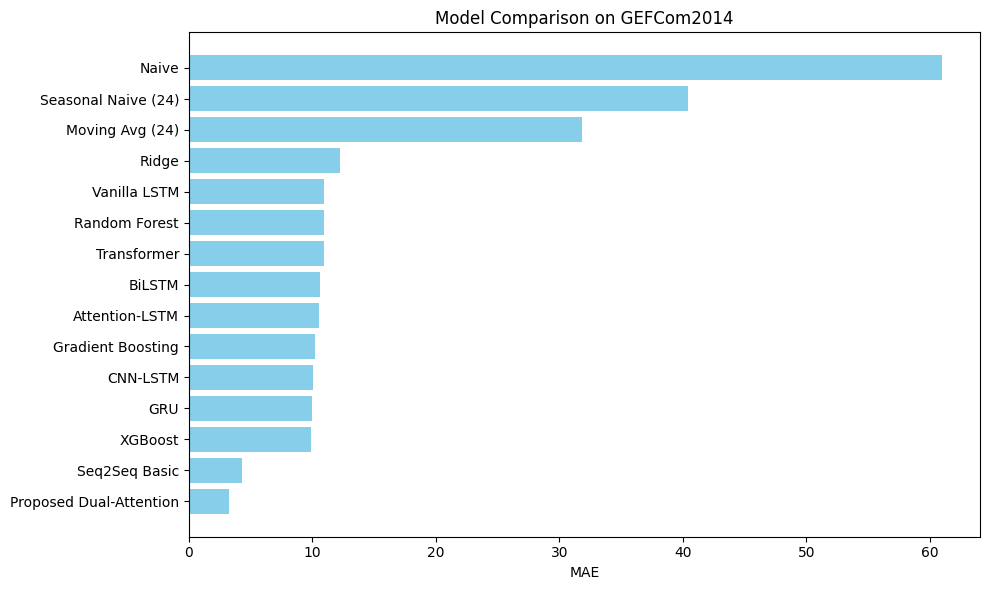


✅ Done. Results saved to 'model_comparison_results_gefcom2014.csv'


In [27]:
# 1. Load data
df, feature_cols, target_col = load_gefcom2014('L1-train.csv', zone=1)  # change zone if needed

# 2. Prepare sequences
(X_train, dec_train, y_train,
 X_val, dec_val, y_val,
 X_test, dec_test, y_test,
 scalers, _) = prepare_enhanced_data(df, input_steps=24, output_steps=12,
                                     target_col=target_col, feature_cols=feature_cols)

print(f"\nData shapes: X_train {X_train.shape}, y_train {y_train.shape}")

# 3. Train the proposed dual‑attention model
print("\n" + "="*80)
print("TRAINING DUAL-ATTENTION MODEL")
print("="*80)

model = create_enhanced_model(
    input_shape=(X_train.shape[1], X_train.shape[2]),
    output_steps=y_train.shape[1],
    num_features=X_train.shape[2],
    lstm_units=128, dense_units=32, dropout_rate=0.2,
    num_heads=4, key_dim=64, l2_reg=0.001, learning_rate=0.001
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=5, min_lr=1e-6, verbose=1),
    tf.keras.callbacks.ModelCheckpoint('best_dual_attention.keras', save_best_only=True)
]

history = model.fit(
    [X_train, dec_train], y_train,
    validation_data=([X_val, dec_val], y_val),
    epochs=80, batch_size=64,
    callbacks=callbacks, verbose=1
)

# 4. Evaluate on test set
y_pred = model.predict([X_test, dec_test], verbose=0)
y_true_unscaled = scalers['target_scaler'].inverse_transform(y_test.reshape(-1,1)).flatten()
y_pred_unscaled = scalers['target_scaler'].inverse_transform(y_pred.reshape(-1,1)).flatten()

test_mae = mean_absolute_error(y_true_unscaled, y_pred_unscaled)
test_rmse = np.sqrt(mean_squared_error(y_true_unscaled, y_pred_unscaled))
test_r2 = r2_score(y_true_unscaled, y_pred_unscaled)
test_mape = np.mean(np.abs((y_true_unscaled - y_pred_unscaled) / (y_true_unscaled + 1e-10))) * 100

print(f"\nProposed model test results:")
print(f"  MAE  = {test_mae:.4f}")
print(f"  RMSE = {test_rmse:.4f}")
print(f"  R²   = {test_r2:.4f}")
print(f"  MAPE = {test_mape:.2f}%")

# 5. Run baseline comparison
comparison = ModelComparison(
    X_train, y_train, X_val, y_val, X_test, y_test,
    dec_train, dec_val, dec_test, scalers
)
results_df = comparison.run_all()

# 6. Append proposed model to results
proposed_row = {
    'model': 'Proposed Dual-Attention',
    'type': 'dl',
    'mae': test_mae,
    'rmse': test_rmse,
    'r2': test_r2,
    'mape': test_mape,
    'time': history.history['loss'][-1],  # placeholder
    'params': model.count_params(),
    'epochs': len(history.history['loss'])
}
results_df = pd.concat([results_df, pd.DataFrame([proposed_row])], ignore_index=True)
results_df = results_df.sort_values('mae').reset_index(drop=True)

print("\n" + "="*80)
print("FINAL RANKING (sorted by MAE)")
print("="*80)
print(results_df[['model', 'mae', 'rmse', 'r2', 'mape', 'time']].to_string(index=False))

# 7. Save results
results_df.to_csv('model_comparison_results_gefcom2014.csv', index=False)

# 8. Optional: plot comparison
plt.figure(figsize=(10,6))
plt.barh(results_df['model'], results_df['mae'], color='skyblue')
plt.xlabel('MAE')
plt.title('Model Comparison on GEFCom2014')
plt.tight_layout()
plt.savefig('model_comparison_gefcom2014.png', dpi=300)
plt.show()

print("\n✅ Done. Results saved to 'model_comparison_results_gefcom2014.csv'")

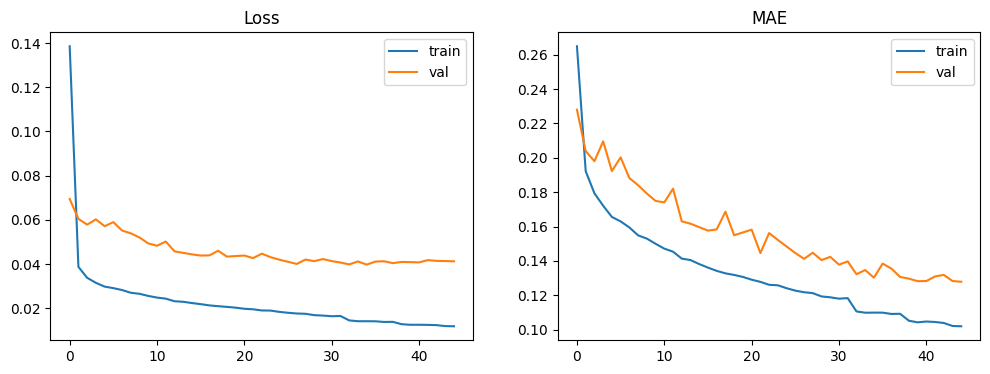

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['mae'], label='train')
plt.plot(history.history['val_mae'], label='val')
plt.title('MAE')
plt.legend()
plt.show()